Using device: cpu
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

=== Training ResNet18 (Seed 123) ===
Epoch [1/3] - Loss: 0.4565 - Val Acc: 91.04%
Epoch [2/3] - Loss: 0.1023 - Val Acc: 92.89%
Epoch [3/3] - Loss: 0.0374 - Val Acc: 93.20%

ResNet18 (Seed 123) Test Accuracy: 93.04%
              precision    recall  f1-score   support

       daisy     0.9541    0.9123    0.9327       114
   dandelion     0.9075    0.9752    0.9401       161
        rose     0.9429    0.8684    0.9041       114
   sunflower     1.0000    0.9091    0.9524       121
       tulip     0.8800    0.9635    0.9199       137

    accuracy                         0.9304       647
   macro avg     0.9369    0.9257    0.9298       647
weighted avg     0.9334    0.9304    0.9305       647



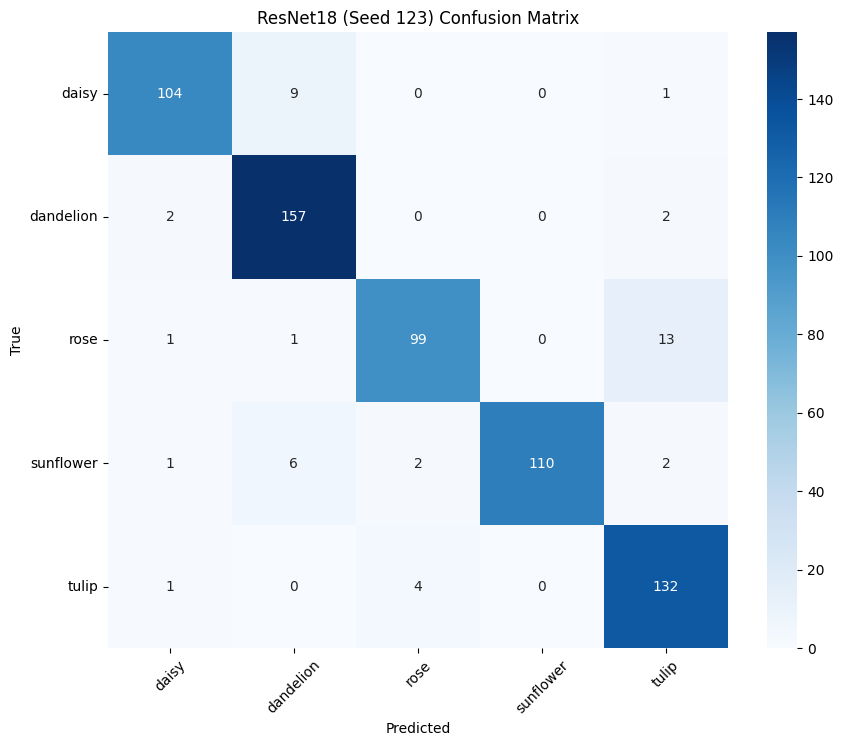


=== Training EfficientNet-B0 (Seed 123) ===
Epoch [1/3] - Loss: 0.8241 - Val Acc: 90.57%
Epoch [2/3] - Loss: 0.2944 - Val Acc: 93.51%
Epoch [3/3] - Loss: 0.1628 - Val Acc: 95.05%

EfficientNet-B0 (Seed 123) Test Accuracy: 92.89%
              precision    recall  f1-score   support

       daisy     0.9444    0.8947    0.9189       114
   dandelion     0.9034    0.9876    0.9436       161
        rose     0.9196    0.9035    0.9115       114
   sunflower     0.9910    0.9091    0.9483       121
       tulip     0.9071    0.9270    0.9170       137

    accuracy                         0.9289       647
   macro avg     0.9331    0.9244    0.9279       647
weighted avg     0.9307    0.9289    0.9288       647



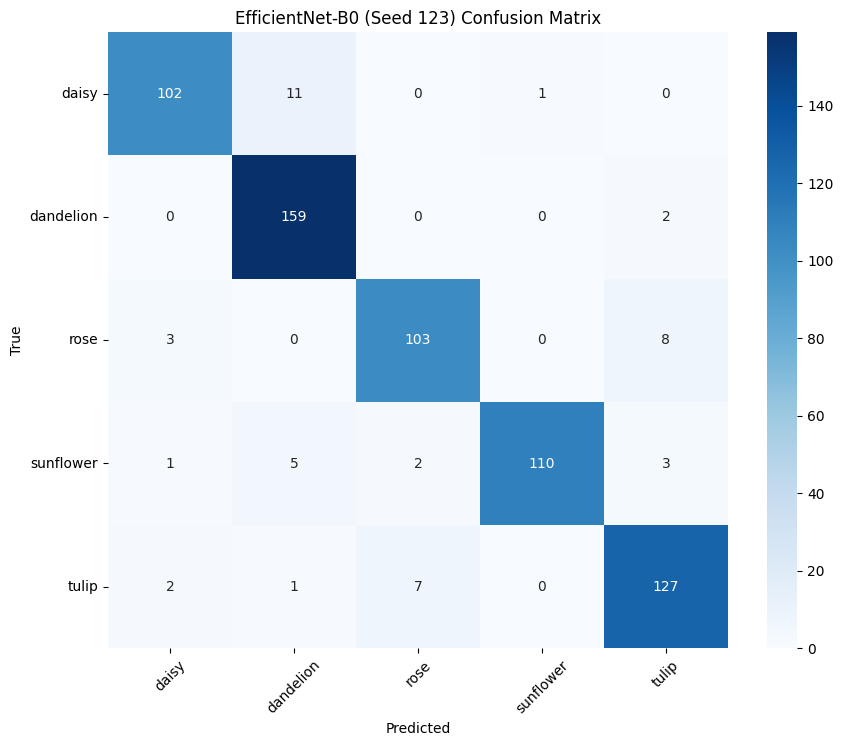


=== Training MobileNetV2 (Seed 123) ===


In [ ]:
# Flower Classification with ResNet18 
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import seaborn as sns

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"
batch_size = 32
image_size = 224  # Standard size for pretrained models
epochs = 3
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"
seeds = [ 123, 456]  # For statistical significance

# ==== ENHANCED DATA TRANSFORMS ====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

# ==== MULTI-MODEL TRAINING FUNCTION ====
def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs, model_name):
    print(f"\n=== Training {model_name} ===")
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_correct += (val_preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_acc = 100 * val_correct / val_total
        train_losses.append(running_loss / len(train_loader))
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.2f}%")

    # Test Evaluation
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            _, test_preds = torch.max(test_outputs, 1)
            test_correct += (test_preds == test_labels).sum().item()
            test_total += test_labels.size(0)
            all_preds.extend(test_preds.cpu().numpy())
            all_labels.extend(test_labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    return test_acc, train_losses, val_accuracies

# ==== MAIN EXPERIMENT LOOP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset once
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create splits with correct transforms
    train_set = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_size = int(0.15 * len(train_set))
    val_size = int(0.15 * len(train_set))
    train_size = len(train_set) - val_size - test_size
    
    train_set, val_set, test_set = random_split(
        train_set, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Apply test transform to val/test
    val_set.dataset.transform = test_transform
    test_set.dataset.transform = test_transform
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    # ==== MODEL COMPARISON ====
    models_dict = {
        'ResNet18': models.resnet18(weights='DEFAULT'),
        'EfficientNet-B0': models.efficientnet_b0(weights='DEFAULT'),
        'MobileNetV2': models.mobilenet_v2(weights='DEFAULT')
    }
    
    for name, model in models_dict.items():
        # Modify final layer
        if 'resnet' in name.lower():
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            if 'efficientnet' in name.lower():
                model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            else:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        acc, _, _ = train_and_evaluate(
            model, train_loader, val_loader, test_loader,
            criterion, optimizer, epochs, f"{name} (Seed {seed})"
        )
        results.append((name, seed, acc))

# ==== STATISTICAL ANALYSIS ====
print("\n=== Final Results ===")
import pandas as pd
df = pd.DataFrame(results, columns=['Model', 'Seed', 'Accuracy'])
print(df.groupby('Model').agg({'Accuracy': ['mean', 'std']}))

# ==== SAVE BEST MODEL ====
best_model = models.resnet18(weights='DEFAULT')
best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(torch.load(model_save_path))
best_model.to(device)
torch.save(best_model.state_dict(), "models/best_flower_model.pth")